<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Aprendizaje Automático Avanzado</h1>
    <h3>Ejemplo: DBSCAN, HDBSCAN y OPTICS</h3>
</div>

Usando el dataset `wine-clustering.csv` crearemos un modelo de clustering DBSCAN

In [36]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
#from pandas_profiling import ProfileReport
%matplotlib inline
#plt.style.use("dark_background")

#### Cargando el dataset

In [37]:
df = pd.read_csv("C:/Users/x/OneDrive - MBGE INTERSISTEMAS/MBGE/DIT/IA/Maestria/Aprendizaje_Automatico_Avanzado_2026/Introducción/data/wine-clustering.csv")
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


#### Análisis Explratorio

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [39]:
df.isna().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

In [40]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [41]:
df.corr

<bound method DataFrame.corr of      Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0      14.23        1.71  2.43          15.6        127           2.80   
1      13.20        1.78  2.14          11.2        100           2.65   
2      13.16        2.36  2.67          18.6        101           2.80   
3      14.37        1.95  2.50          16.8        113           3.85   
4      13.24        2.59  2.87          21.0        118           2.80   
..       ...         ...   ...           ...        ...            ...   
173    13.71        5.65  2.45          20.5         95           1.68   
174    13.40        3.91  2.48          23.0        102           1.80   
175    13.27        4.28  2.26          20.0        120           1.59   
176    13.17        2.59  2.37          20.0        120           1.65   
177    14.13        4.10  2.74          24.5         96           2.05   

     Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  

#### Escalamiento de los Datos

In [42]:
scale = StandardScaler()
data = scale.fit_transform(df)
pd.DataFrame(data)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952
174,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893
175,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575
176,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498


In [43]:
pca = PCA(n_components=13)
pca.fit(data)
data_pca = pca.transform(data)
pd.DataFrame(data_pca)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0.223880,0.596427,-0.065139,-0.641443,1.020956,-0.451563,0.540810,-0.066239
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0.927120,0.053776,-1.024416,0.308847,0.159701,-0.142657,0.388238,0.003637
2,2.516740,1.031151,0.982819,0.724902,-0.251033,-0.549276,0.424205,0.344216,1.177834,0.113361,-0.286673,0.000584,0.021717
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,-0.114431,-0.383337,-0.643593,-0.052544,0.239413,0.759584,-0.242020,-0.369484
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0.406520,0.444074,-0.416700,-0.326819,-0.078366,-0.525945,-0.216664,-0.079364
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,-3.370524,2.216289,-0.342570,1.058527,-0.574164,1.108788,0.958416,0.146097,0.022498,-0.304117,0.139228,0.170786,-0.114427
174,-2.601956,1.757229,0.207581,0.349496,0.255063,0.026465,0.146894,0.552427,0.097969,-0.206061,0.258198,-0.279431,-0.187371
175,-2.677839,2.760899,-0.940942,0.312035,1.271355,-0.273068,0.679235,-0.047024,-0.001222,-0.247997,0.512492,0.698766,0.072078
176,-2.387017,2.297347,-0.550696,-0.688285,0.813955,-1.178783,0.633975,-0.390829,-0.057448,0.491490,0.299822,0.339821,-0.021866


In [44]:
pca.explained_variance_ratio_

array([0.36198848, 0.1920749 , 0.11123631, 0.0706903 , 0.06563294,
       0.04935823, 0.04238679, 0.02680749, 0.02222153, 0.01930019,
       0.01736836, 0.01298233, 0.00795215])

In [45]:
sum(pca.explained_variance_ratio_[:5])

0.8016229275554787

In [46]:
pca = PCA(n_components=4)
pca.fit(data)
df_pca = pca.transform(data)
pd.DataFrame(df_pca)

,0,1,2,3
0,3.316751,1.443463,-0.165739,-0.215631
1,2.209465,-0.333393,-2.026457,-0.291358
2,2.516740,1.031151,0.982819,0.724902
3,3.757066,2.756372,-0.176192,0.567983
4,1.008908,0.869831,2.026688,-0.409766
...,...,...,...,...
173,-3.370524,2.216289,-0.342570,1.058527
174,-2.601956,1.757229,0.207581,0.349496
175,-2.677839,2.760899,-0.940942,0.312035
176,-2.387017,2.297347,-0.550696,-0.688285


#### Selección de los parámetros para el clustering

In [47]:
# eps ?, min_samples ?
min_samples = 4
neig = NearestNeighbors(n_neighbors=min_samples)
nbrs = neig.fit(df_pca)
dis, ind = nbrs.kneighbors(df_pca)

In [48]:
k_distances = np.sort(dis[:,min_samples-1], axis=0)
k_distances

array([0.50692128, 0.53627821, 0.54236572, 0.56763288, 0.57266556,
       0.58079201, 0.58905004, 0.59393548, 0.60032315, 0.60058628,
       0.61239256, 0.62327751, 0.64322523, 0.65126303, 0.65572065,
       0.66260121, 0.67236592, 0.6746659 , 0.67758744, 0.68801601,
       0.68819792, 0.69352875, 0.70800925, 0.71235945, 0.72191702,
       0.72369746, 0.73016347, 0.75306424, 0.75306424, 0.75335773,
       0.75440357, 0.76009617, 0.7617693 , 0.76291152, 0.76291152,
       0.76506562, 0.76748175, 0.76867177, 0.7741981 , 0.77774019,
       0.781017  , 0.78800603, 0.79198528, 0.80560867, 0.80771474,
       0.80771474, 0.8098448 , 0.81057848, 0.81866216, 0.82349057,
       0.83212565, 0.83299333, 0.83423674, 0.83423674, 0.83962937,
       0.84554378, 0.84826381, 0.8490024 , 0.85213639, 0.85586415,
       0.85586415, 0.86107903, 0.86982292, 0.87643104, 0.88148995,
       0.88157243, 0.88157243, 0.88417042, 0.88417042, 0.88921608,
       0.90392043, 0.90719446, 0.91052153, 0.91131225, 0.91462

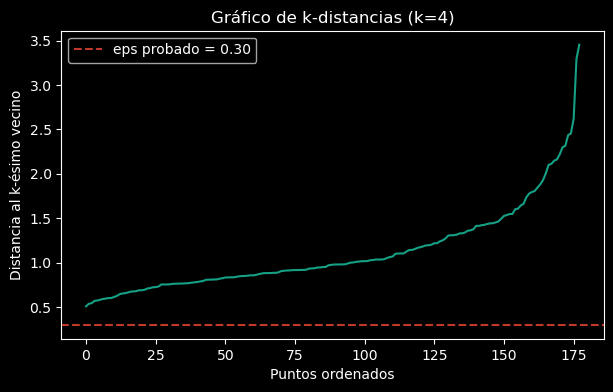

In [49]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_distances, color='#16a085')
ax.set(title=f'Gráfico de k-distancias (k={min_samples})', xlabel='Puntos ordenados', ylabel='Distancia al k-ésimo vecino')
ax.axhline(0.30, color='#c0392b', linestyle='--', label='eps probado = 0.30')
ax.legend()
plt.show()

### Modelo de clustering por DBSCAN

In [50]:
cluster = DBSCAN(eps=0.50, min_samples=min_samples)
df_pca_new = df_pca.copy()
df_pca_new['clust_dbscan'] = cluster.fit_predict(df_pca)
df_pca_new

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [35]:
df_pca_new.columns = ['x1','x2','x3','x4','clust_dbscan']

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

#### Mostrando los clusters

In [34]:
plt.figure(figsize=(15, 12))
sns.scatterplot(x='x1',y='x2',data=df_pca_new,hue='clust_dbscan',palette='tab10',s=200)

TypeError: Data source must be a DataFrame or Mapping, not <class 'numpy.ndarray'>.

<Figure size 1500x1200 with 0 Axes>

In [ ]:
df_new['Label'].unique()

## Tarea 1: 

Aplique HDBSCAN y OPTICS a este conjunto de datos, muestra distribuciones, compare los modelosm obtenga gráficas y concluya cuál obtiene mejores resultados.